In [22]:
!pip install gseapy statsmodels seaborn matplotlib pandas numpy scipy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import gseapy as gp

print("All packages imported successfully!")

All packages imported successfully!


In [23]:
np.random.seed(42)
genes = [f"GENE_{i}" for i in range(1, 1001)]
# Insert known cancer/immune genes for pathway enrichment testing
genes[:10] = ['TP53', 'EGFR', 'MYC', 'BRCA1', 'VEGFA', 'IL6', 'TNF', 'STAT3', 'AKT1', 'MTOR']

# Generate baseline expression counts
control_data = np.random.poisson(lam=100, size=(1000, 3))
treatment_data = np.random.poisson(lam=100, size=(1000, 3))

# Induce differential expression in top 10 genes
treatment_data[:5, :] = treatment_data[:5, :] * 4.5  # Up-regulated
treatment_data[5:10, :] = treatment_data[5:10, :] * 0.2  # Down-regulated

df_control = pd.DataFrame(control_data, index=genes, columns=['Ctrl_1', 'Ctrl_2', 'Ctrl_3'])
df_treatment = pd.DataFrame(treatment_data, index=genes, columns=['Treat_1', 'Treat_2', 'Treat_3'])
counts = pd.concat([df_control, df_treatment], axis=1)

# Log2 normalization
norm_counts = np.log2(counts + 1)
print("Data matrix successfully created! Matrix shape:", norm_counts.shape)

Data matrix successfully created! Matrix shape: (1000, 6)


In [24]:
# Check the dimensions of our raw count matrix
print("Count matrix shape:", counts.shape)

# Display the first five genes
display(counts.head())

# Check whether gene names are unique
print("Unique gene names:", counts.index.nunique())

# Check for missing values
print("Missing values:", counts.isna().sum().sum())

# Check whether all counts are integers
print("All counts are integers:",
      (counts.to_numpy() % 1 == 0).all())

Count matrix shape: (1000, 6)


,Ctrl_1,Ctrl_2,Ctrl_3,Treat_1,Treat_2,Treat_3
TP53,96,107,88,436,472,459
EGFR,103,111,90,441,418,454
MYC,94,98,103,490,468,535
BRCA1,94,99,90,481,405,513
VEGFA,103,103,94,531,450,495


Unique gene names: 1000
Missing values: 0
All counts are integers: True


In [25]:
!pip install pydeseq2

In [26]:
ctrl_cols = ['Ctrl_1', 'Ctrl_2', 'Ctrl_3']
treat_cols = ['Treat_1', 'Treat_2', 'Treat_3']

# Calculate log2 fold change and p-values
log2fc = norm_counts[treat_cols].mean(axis=1) - norm_counts[ctrl_cols].mean(axis=1)
pvals = ttest_ind(norm_counts[treat_cols], norm_counts[ctrl_cols], axis=1).pvalue

# Adjust p-values using Benjamini-Hochberg (FDR)
fdr = multipletests(pvals, method='fdr_bh')[1]

results = pd.DataFrame({'log2FC': log2fc, 'pvalue': pvals, 'padj': fdr}, index=genes)

# Categorize significance
results['expression'] = 'Not Significant'
results.loc[(results['log2FC'] > 1) & (results['padj'] < 0.05), 'expression'] = 'Up-regulated'
results.loc[(results['log2FC'] < -1) & (results['padj'] < 0.05), 'expression'] = 'Down-regulated'

print(results['expression'].value_counts())

expression
Not Significant    990
Up-regulated         5
Down-regulated       5
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


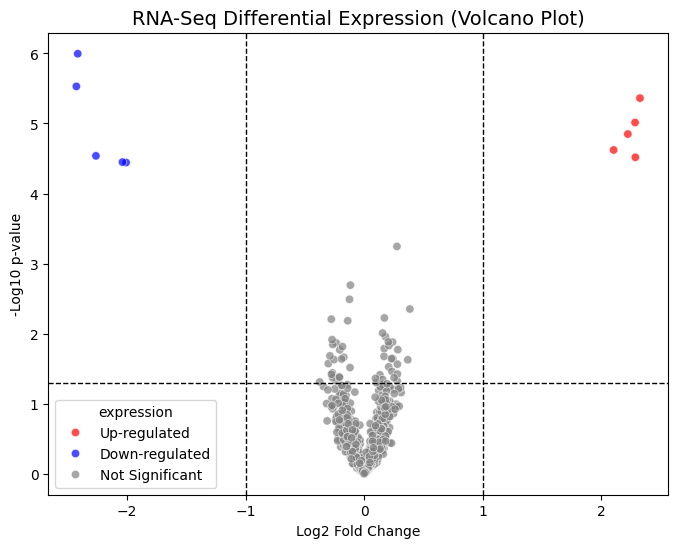

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results,
    x='log2FC',
    y=-np.log10(results['pvalue']),
    hue='expression',
    palette={'Up-regulated': 'red', 'Down-regulated': 'blue', 'Not Significant': 'grey'},
    alpha=0.7
)

plt.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1)
plt.axvline(1, linestyle='--', color='black', linewidth=1)
plt.axvline(-1, linestyle='--', color='black', linewidth=1)
plt.title('RNA-Seq Differential Expression (Volcano Plot)', fontsize=14)
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 p-value')

plt.savefig('volcano_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
up_genes = results[results['expression'] == 'Up-regulated'].index.tolist()

if up_genes:
    print("Top Up-regulated Genes identified:", up_genes)
    enr = gp.enrichr(
        gene_list=up_genes,
        gene_sets='KEGG_2021_Human',
        outdir='enrichment_kegg'
    )
    print("Pathway enrichment successfully completed!")

Top Up-regulated Genes identified: ['TP53', 'EGFR', 'MYC', 'BRCA1', 'VEGFA']
Pathway enrichment successfully completed!
